In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Lab 07: EM Algorithm

In this session, we explore the frequentist parameter inference of the Gaussian Mixture Model (GMM). The GMM is defined as the following generative process: For each point $n$:
* Choose a cluster $z_n \in \lbrace 1, \dotsc, K \rbrace$ with probability $p(x_n = k) = \pi_k$
* Draw $x_n$ from normal distribution $\mathcal{N}(\mu_{z_n}, \Sigma_{z_n})$. 

The likelihood of the parameters $\theta$ of the GMM for the point $x_n$ is then:
$$
p_{\theta}(x_n) = \sum_{k=1}^K \pi_k \, \mathcal{N}(x_n: \mu_{k}, \Sigma_{k})
$$


In this session, we will compute the Maximum Likelihood estimator of $\theta$ using the EM algorithm. 


## A test dataset

To test our algorithm, we use the blob dataset generation of the scikit-learn library. This generator creates a dataset evenly distributed among $K$ multivariate normal distributions. We propose several variants of this dataset:
* _Standard:_ The points are evenly distributed among clusters, and all distributions have the same spherical covariance $\Sigma_k = \sigma^2 I$
* _Anisotropic:_ Differs from the standard case on the fact that the covariances are still the same, but not spherical.
* _Unequal variance:_ All distributions are different but spherical covariance. 
* _Unevenly distributied:_ All clusters have the same spherical covariance, but the points are unevenly distributed between clusters. 


In [3]:
# Dataset hyperparameters

n_samples = 1500
seed= 3456789
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

In [4]:
# Generation of the datasets

X, y = make_blobs(n_samples=n_samples, random_state=seed)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=seed
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

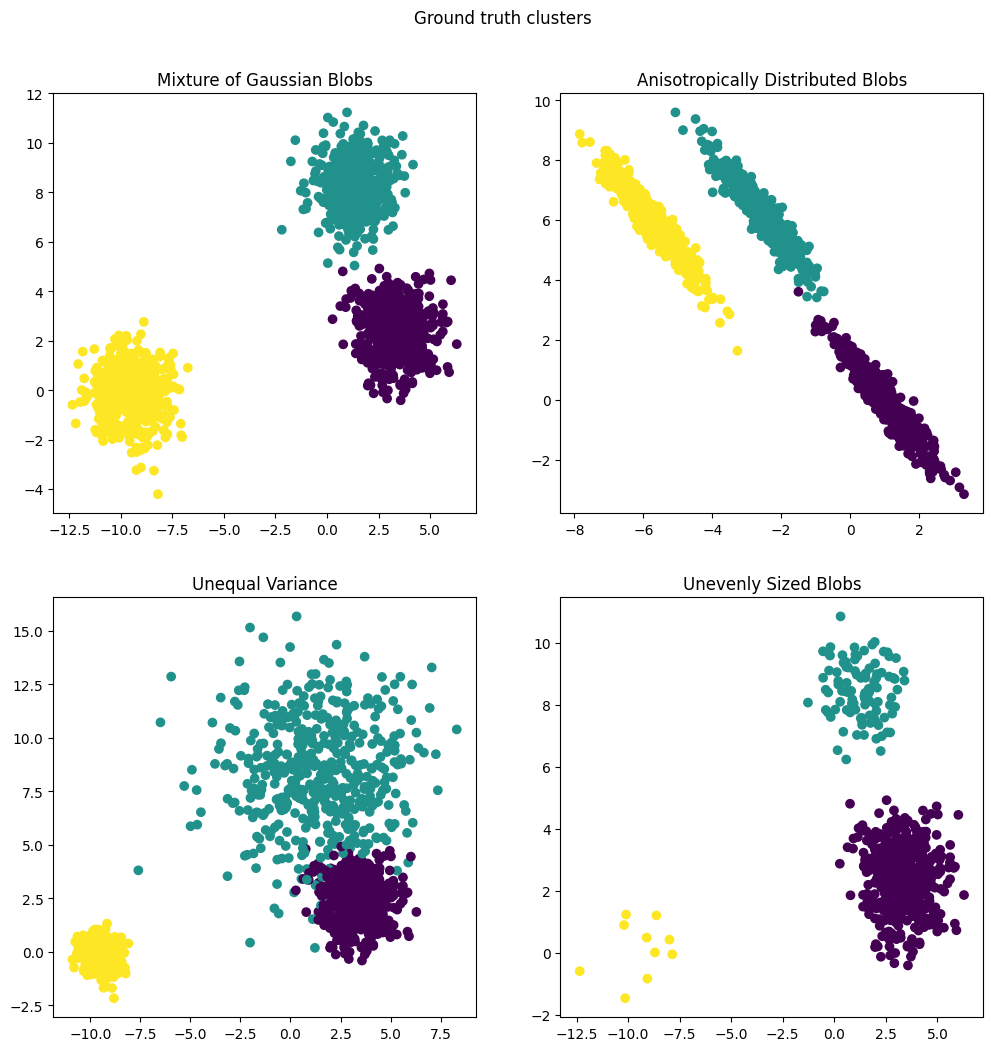

In [6]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[0, 1].set_title("Anisotropically Distributed Blobs")

axs[1, 0].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 0].set_title("Unequal Variance")

axs[1, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[1, 1].set_title("Unevenly Sized Blobs")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

## E Step

In the E Step, the goal is to compute the quantity:
$$
Q_n(\theta; \theta^{(t)}) = \mathbb{E}_{z_n \sim p(. | x_n)}[\log p_{\theta}(x_n, z_n) ]
$$
The total ELBO is the sum over the $Q_n$: 
$$
Q(\theta; \theta^{(t)}) = \sum_{n=1}^N Q_n(\theta; \theta^{(t)})
$$

#### Question 1

a) Assuming that we are fixing the parameter $\theta^{(t)}$, compute the posterior $r_{nk} = p(z_n = k | x_n)$.<br>
b) Compute $Q(\theta; \theta^{(t)})$. 

### <font color='green'><u>Solution</u></font>
a) By Bayes' rule,
$$p(z_n = k \mid x_n) = \frac{p(x_n \mid z_n = k) p(z_n = k)}{p(x_n)} = \frac{\pi_k^{(t)} \mathcal N(x_n; \mu_k^{(t)}, \Sigma_k^{(t)})}{\sum_{j=1}^K \pi_j^{(t)} \mathcal N(x_n; \mu_j^{(t)}, \Sigma_j^{(t)})}.$$

b) Using the above result, for each $n \in \{1,\dots,N\}$, we have
$$Q_n(\theta; \theta^{(t)}) = \sum_{k=1}^K r_{nk}^{(t)} \log \pi_k + \sum_{k=1}^K r_{nk}^{(t)} \log \mathcal N(x_n; \mu_k, \Sigma_k).$$
Therefore,
$$Q(\theta; \theta^{(t)}) = \sum_{n=1}^N \sum_{k=1}^K r_{nk}^{(t)} \log \pi_k + \sum_{n=1}^N \sum_{k=1}^K r_{nk}^{(t)} \log \mathcal N(x_n; \mu_k, \Sigma_k).$$

## M Step

In the M step, we maximize the $Q$ function over $\theta$. We will not do the whole calculation in this session, but we will just see how to estimate $(\pi_1, \dotsc, \pi_K)$. 

#### Question 2

Compute the derivate of $Q$ with respect to $\pi_k$. Show that the gradient does not vanish. This is incoherent: find the mistake and correct it!

### <font color='green'><u>Solution</u></font>
If we naively differentiate, we get the following expression,
$$\frac{\partial Q}{\partial \pi_k} = \frac{1}{\pi_k}\sum_{n=1}^N r_{nk}^{(t)},$$
which is always positive.

The issue is that we are completely ignoring the constraint $\sum_k \pi_k = 1$.
There are two alternatives to approach this:
1. Using a Lagrangian.
> **Lagrangian approach:** To incorporate this, we can construct a Lagrangian
$$\mathcal L(\theta; \theta^{(t)}) = Q(\theta; \theta^{(t)}) - \alpha (1 - \sum_{k=1}^K \pi_k),$$
for which we have
$$\frac{\partial \mathcal L}{\partial \pi_k} = \frac{r_k}{\pi_k} + \alpha = 0 \iff \pi_k = \frac{r_k}{-\alpha}.$$
Using the constraint one more time, we see that $$1 = \sum_k \pi_k = \frac 1 {-\alpha} \sum_k r_k = \frac 1 {-\alpha} \sum_k \sum_n r_{kn} = \frac 1 {-\alpha} \sum_n \underbrace{\sum_k r_{kn}}_{=1} = \frac 1 {-\alpha} N,$$
meaning that $\alpha = -N$, giving us the desired expression for $\pi_k$.

2. Optimizing over $K-1$ variables only and setting $\pi_K = 1 - \sum_{k=1}^{K-1} \pi_k$.
> **Reparametrization approach:** Computing the gradient with respect to this reparametrization gives us the following gradients:
$$\frac{\partial Q}{\partial \pi_k} = \frac{1}{\pi_k}\sum_{n=1}^N r_{nk}^{(t)} - \frac{1}{\pi_K} \sum_{n=1}^N r_{nK}^{(t)} = \frac{r_k^{(t)}}{\pi_k} - \frac{r_K^{(t)}}{\pi_K}.$$
Setting this to 0 for all $k$ means
$$\frac{r_k^{(t)}}{\pi_k} = \frac{r_K^{(t)}}{\pi_K} \quad \forall k\in\{1,\dots,K-1\}.$$
Because the right-hand-side is the same in each of the equations, we can conclude that
$$\frac{r_1^{(t)}}{\pi_1} = \frac{r_2^{(t)}}{\pi_2} = \dots = \frac{r_K^{(t)}}{\pi_K} = c,$$
where $c \in \mathbb R$ is some constant. Consequently, $$c = c \sum_{k=1}^K \pi_k = \sum_{k=1}^K r_k^{(t)} = \sum_{k=1}^K \sum_{n=1}^N r_{nk}^{(t)} = \sum_{n=1}^N \underbrace{\sum_{k=1}^K r_{nk}^{(t)}}_{=1} = N,$$
and hence $\pi_k = r_k^{(t)} / N$.

The formulae of the optimized parameters are given in the lecture:

$$
\pi_k^{(t+1)} = \frac{1}{N} \sum_{n=1}^N r_{nk}^{(t)} = \frac{r_k}{N} \qquad \qquad \mu_k^{(t+1)} = \frac{\sum_{n=1}^N r_{nk}^{(t)} x_n}{r_k} \qquad \qquad \Sigma_k^{(t+1)} = \frac{1}{r_k}  \sum_{n=1}^N r_{nk}^{(t)} (x_n - \mu_k) (x_n - \mu_k)^T 
$$

In our code, we will group all the parameters in a dictionary:

In [10]:
K = 3
d = 2

theta_t = { 'pi': np.ones((K,)) / K,
            'mu': np.random.rand(K, d), 
            'sigma': [np.eye(d) for _ in range(K)]}

In [8]:
theta_t

{'pi': array([0.33333333, 0.33333333, 0.33333333]),
 'mu': array([[0.92079875, 0.74708238],
        [0.158121  , 0.83776933],
        [0.22324924, 0.39363869]]),
 'sigma': [array([[1., 0.],
         [0., 1.]]),
  array([[1., 0.],
         [0., 1.]]),
  array([[1., 0.],
         [0., 1.]])]}

#### Question 3

Implement the parameter update.

### <font color='green'><u>Solution</u></font>

In [11]:
from scipy.stats import multivariate_normal

def parameter_update(theta_t, X):
    ### SOLUTION
    new_theta = dict()
    # 1. Compute the responsibilities.
    N = X.shape[0]
    r = np.zeros((N,K))
    for k in range(K):
        mu = theta_t['mu'][k]
        sigma = theta_t['sigma'][k]
        r[:,k] = theta_t['pi'][k] * multivariate_normal.pdf(X, mean=mu, cov=sigma)
    r /= r.sum(axis = 1, keepdims=True)

    # 2. Update parameters.
    rk = r.sum(axis=0)
    new_theta['pi'] = rk / N
    new_theta['mu'] = (r.T @ X) / rk[:,None]
    new_theta['sigma'] = np.zeros_like(theta_t['sigma'])
    for k in range(K):
        diff = X - theta_t['mu'][k]
        new_theta['sigma'][k] = (diff.T @ (diff * r[:,k,None])) / rk[k]
    
    return new_theta

In [12]:
### Code used to compute the log-likelihood

# Example usage
xs = np.array([
    [1.0, 2.0],
    [0.0, 1.0],
    [2.0, 1.5]
])  # Batch of observations (3 samples, 2 features)

mu = np.array([0.0, 0.0])  # Mean vector
sigma = np.array([[1.0, 0.5], [0.5, 1.0]])  # Covariance matrix

pdf_values = multivariate_normal.pdf(xs, mean=mu, cov=sigma)
print("Likelihood (PDF) values for the observations:")
print(pdf_values)


def multivariate_normal_pdf_batch_cluster(xs, mus, sigmas, K):
    return np.array([multivariate_normal.pdf(X, mean=mus[k], cov=sigmas[k]) for k in range(K)])


def loglikelihood_gmm(theta, X):
    likelihoods = theta['pi'][:,None] * multivariate_normal_pdf_batch_cluster(X, theta['mu'], theta['sigma'], K)
    log_n = np.log(likelihoods.sum(0))
    return log_n.sum()


Likelihood (PDF) values for the observations:
[0.02487142 0.0943539  0.0210532 ]


#### Question 4

Implement the EM algorithm, taking as input the dataset ```X```, the initial ```theta``` as well as all the parameters you think are useful. You will need to define a termination criterion for your algorithm. What would be a debugging test that you might want to run?

### <font color='green'><u>Solution</u></font>
As a termination criterion, we can stop once the increase in log likelihood is below a certain threshold, such as $10^{-10}$ in this case.

In [13]:
def EM(X, theta):
    llh = loglikelihood_gmm(theta, X)
    diff = 1
    while diff > 1e-10:
        theta = parameter_update(theta, X)
        diff = loglikelihood_gmm(theta, X) - llh
        llh += diff
    return theta

## GMM for clustering

We now propose to see how the GMM can be used for clustering. By design of the model, GMM is a _soft clustering_ method, in the sense that it provides the probability of a point to belong to a cluster, but not a cluster allocation. To make it a _hard clustering_, we allocate each point to its most likely cluster. 

In [14]:
def allocate_points(X, theta, K):
    likelihoods = multivariate_normal_pdf_batch_cluster(X, theta['mu'], theta['sigma'], K)
    return np.argmax(likelihoods, axis=0)

The following code implements a visualization method for a produced clustering:

In [15]:
def visualize_clustering(X, clusters):
    plt.scatter(X[:, 0], X[:, 1], c=clusters)
    plt.show()

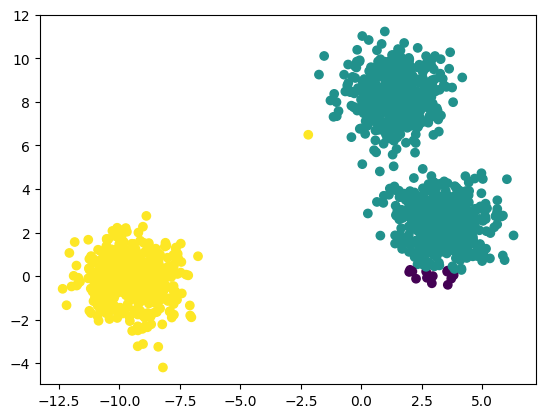

In [16]:
visualize_clustering(X, allocate_points(X, theta_t, K))

#### Question 5

Visualize the evolution of the clusters at each step of the EM for the four datasets. Test different initializations. Which one seems the most reasonable? How would you propose an initialization for $\theta$? Test the behaviour of the algorithm for $K > 3$. How would you choose the optimal number of clusters?

### <font color='green'><u>Solution</u></font>
The relevant code for this task is below. The questions can be answered through experimentation.

In [17]:
def EM_cluster(X, theta):
    llh = loglikelihood_gmm(theta, X)
    visualize_clustering(X, allocate_points(X, theta, K))
    diff = 1
    while diff > 1e-10:
        theta = parameter_update(theta, X)
        diff = loglikelihood_gmm(theta, X) - llh
        llh += diff
        visualize_clustering(X, allocate_points(X, theta, K))
    return theta

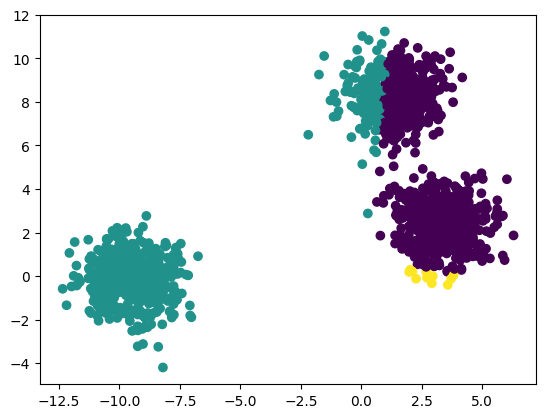

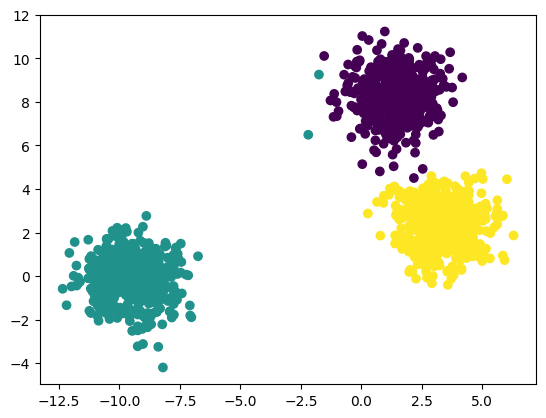

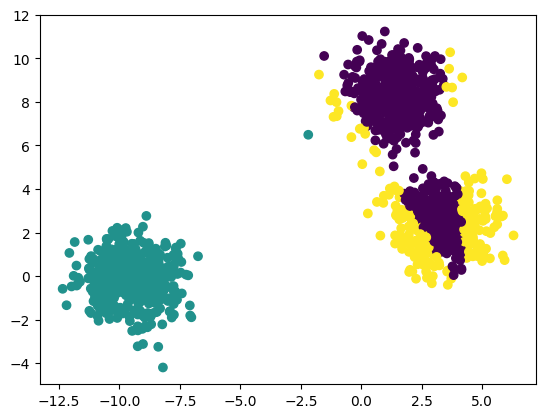

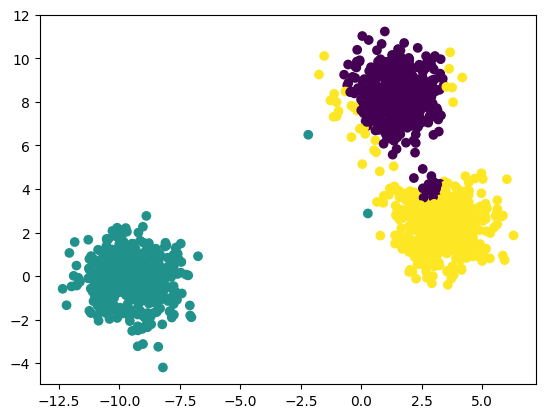

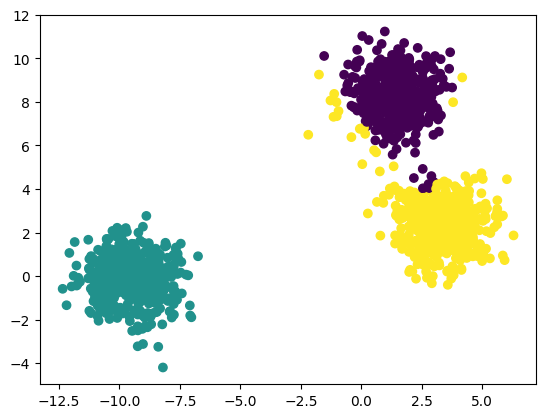

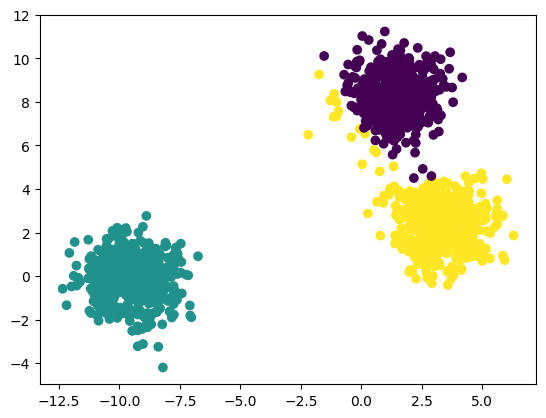

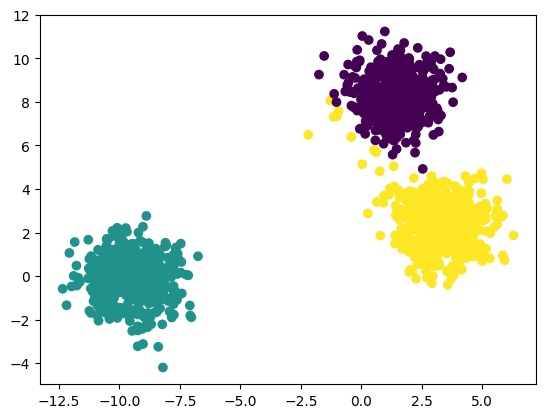

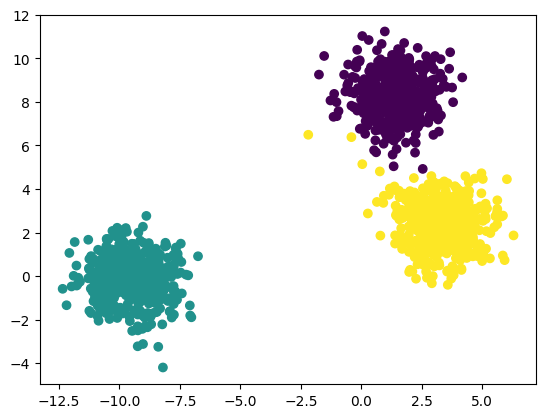

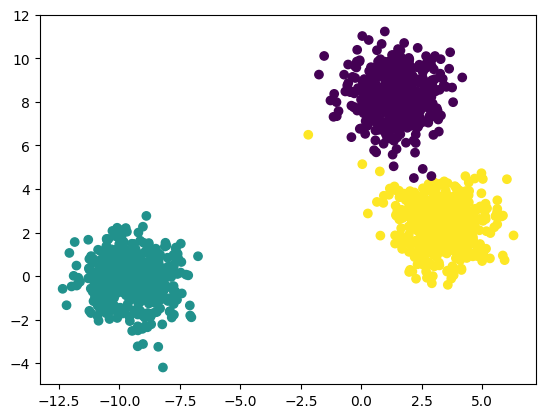

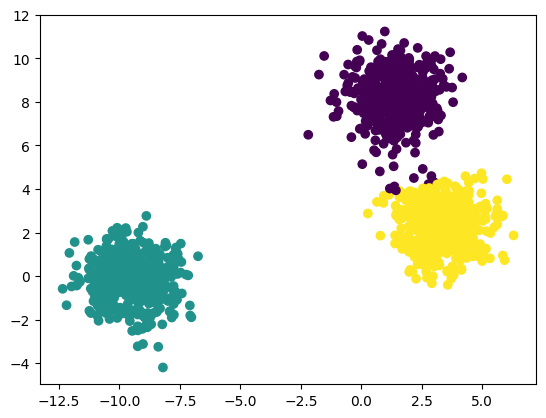

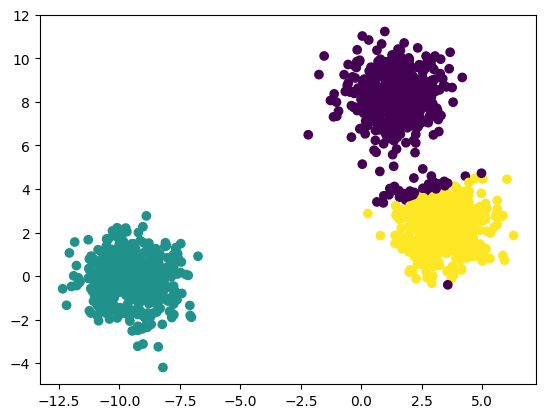

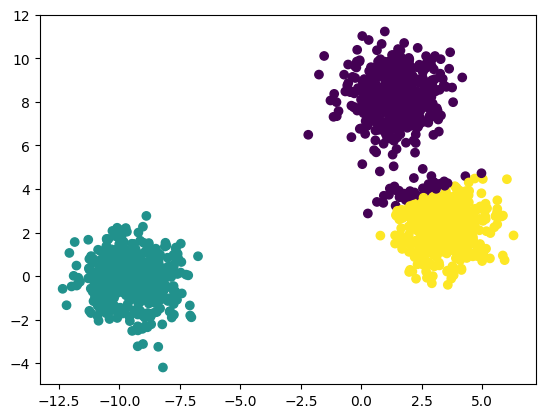

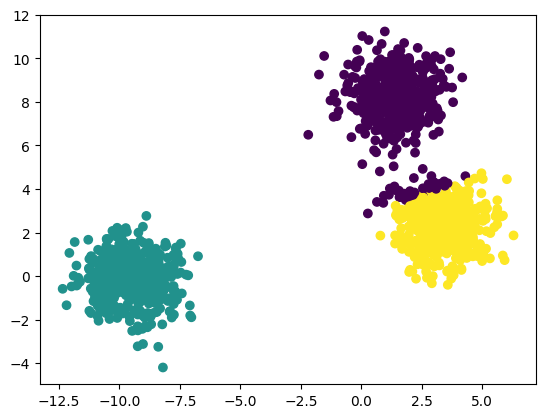

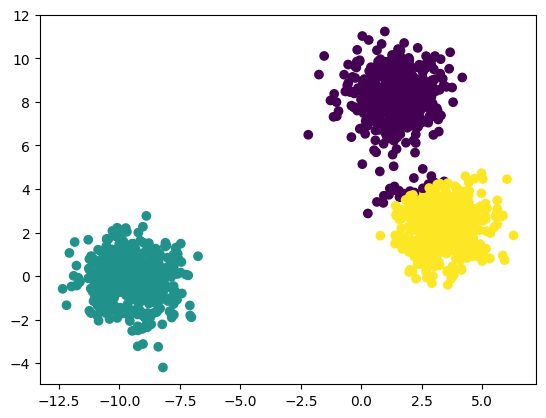

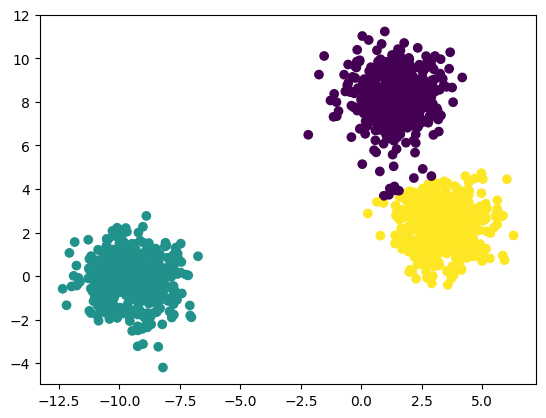

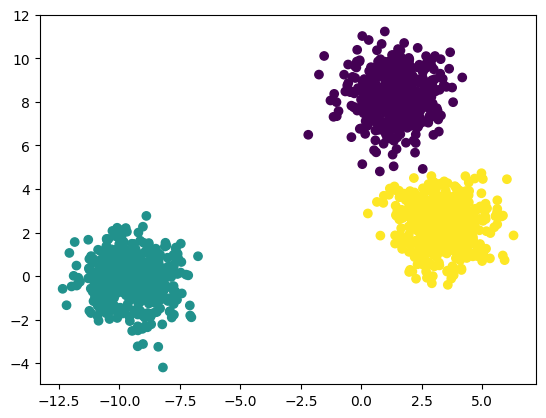

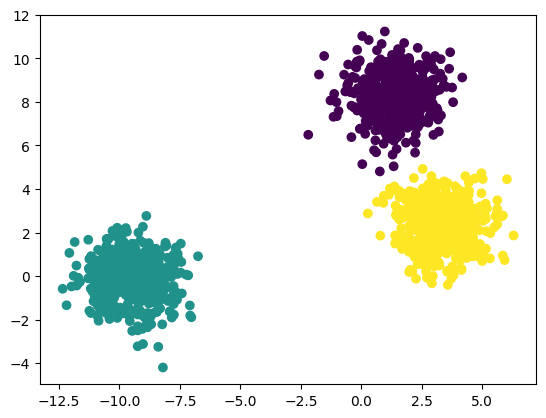

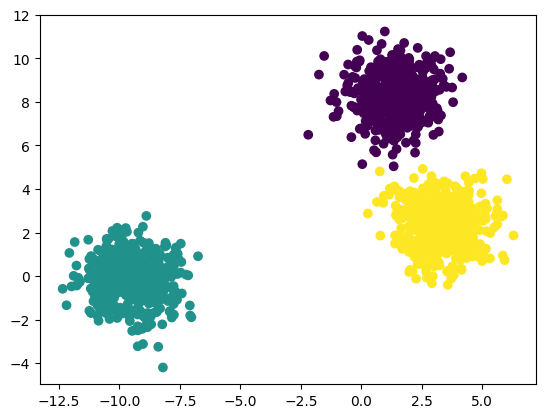

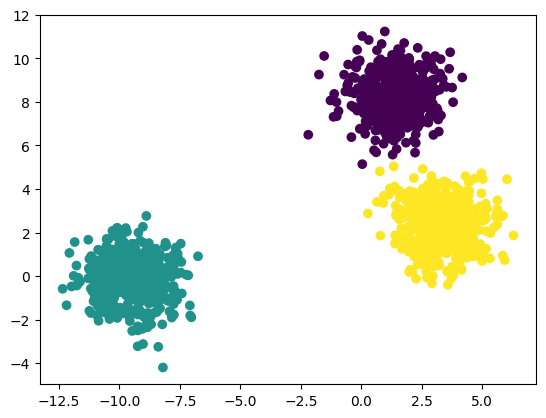

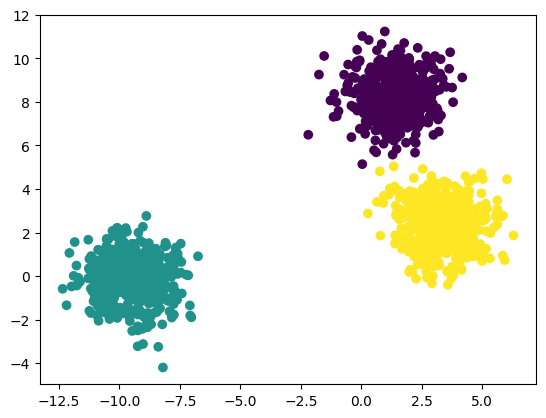

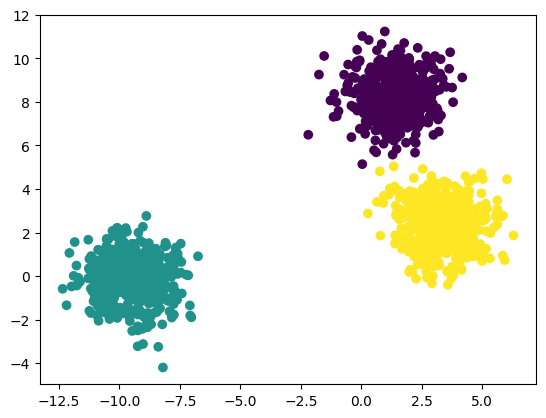

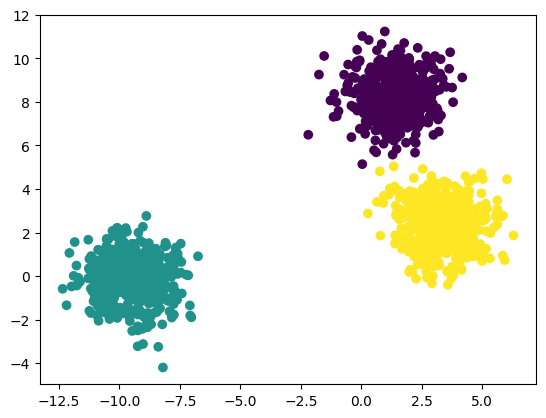

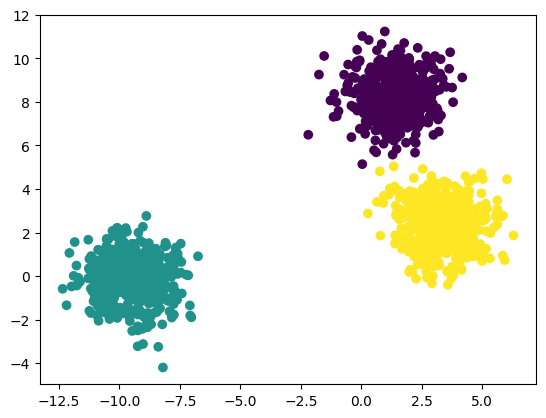

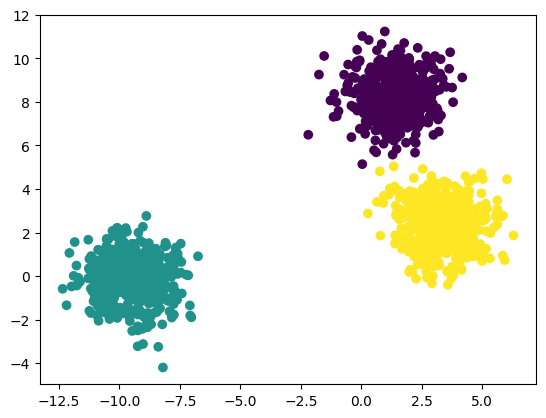

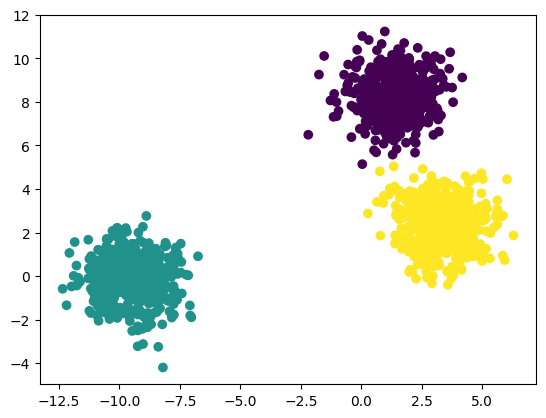

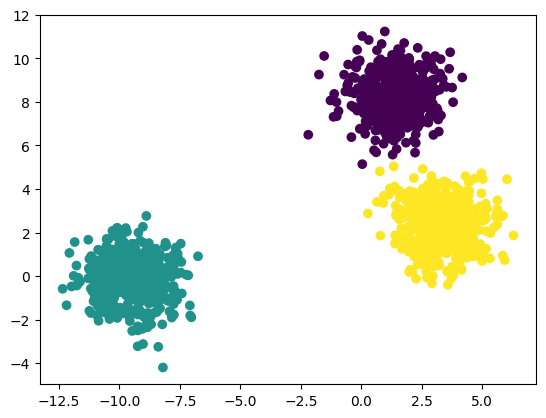

{'pi': array([0.33308993, 0.33333333, 0.33357673]),
 'mu': array([[ 1.40128867,  8.2823399 ],
        [-9.44013994, -0.17258177],
        [ 3.34450169,  2.41478407]]),
 'sigma': array([[[ 0.95350208,  0.02151827],
         [ 0.02151827,  1.00884384]],
 
        [[ 1.00798907, -0.06995244],
         [-0.06995244,  0.98390673]],
 
        [[ 1.02844855, -0.05371257],
         [-0.05371257,  1.0324772 ]]])}

In [18]:
theta_t = { 'pi': np.ones((K,)) / K,
            'mu': np.random.rand(K, d), 
            'sigma': [np.eye(d) for _ in range(K)]}

EM_cluster(X, theta_t)